In [1]:
import os
import joblib
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
biogas = pd.read_csv("interpolated_biogas_data_8000.csv")

biogas

,Hydraulic Retention Time (Days),Temperature (°C),pH,Biogas Yield (m³/Kg),CH4 (%)
0,12,30,6.94,0.24,18.56
1,30,28,6.96,0.46,60.21
2,8,29,6.88,0.13,3.95
3,26,35,7.13,0.45,60.08
4,7,31,6.84,0.12,4.39
...,...,...,...,...,...
7995,3,29,6.75,0.03,5.65
7996,29,32,7.01,0.47,61.09
7997,21,32,7.03,0.41,50.05
7998,28,33,7.06,0.44,63.22


In [6]:
biogas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Hydraulic Retention Time (Days)  8000 non-null   int64  
 1   Temperature (°C)                 8000 non-null   int64  
 2   pH                               8000 non-null   float64
 3   Biogas Yield (m³/Kg)             8000 non-null   float64
 4   CH4 (%)                          8000 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 312.6 KB


In [7]:
biogas.describe().T

,count,mean,std,min,25%,50%,75%,max
Hydraulic Retention Time (Days),8000.0,15.064875,8.967551,0.00,7.0000,15.000,23.0000,30.00
Temperature (°C),8000.0,31.641750,2.349063,25.00,30.0000,32.000,34.0000,36.00
pH,8000.0,6.937578,0.119188,6.63,6.8400,6.970,7.0200,7.15
Biogas Yield (m³/Kg),8000.0,0.277494,0.156105,0.00,0.1400,0.320,0.4300,0.48
CH4 (%),8000.0,31.731809,23.280923,0.00,5.6075,36.525,54.5225,63.72


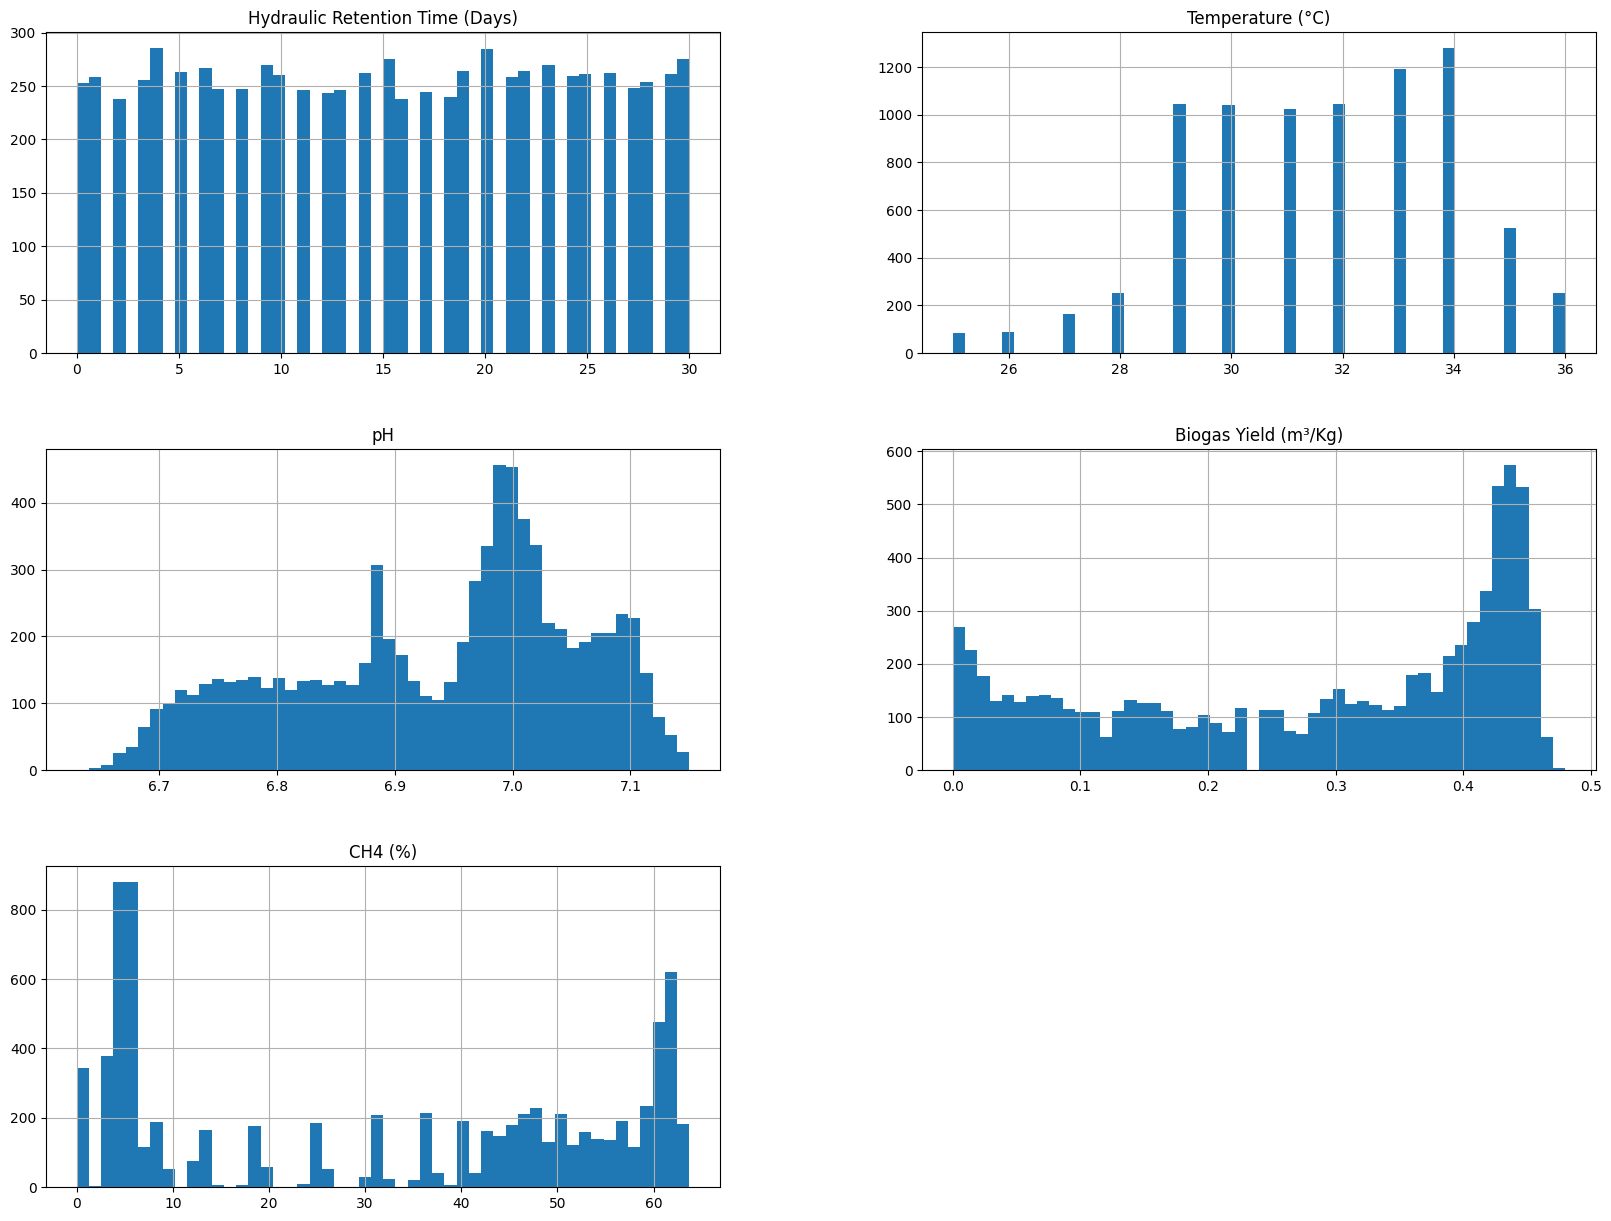

In [8]:
biogas.hist(bins=50, figsize=(20,15))
plt.show()

In [9]:
#to show correlation of two columns
correlation = biogas["Biogas Yield (m³/Kg)"].corr(biogas["CH4 (%)"])
print(f"correlation between Biogas Yield and CH4 produced: {correlation:.4f}")

correlation between Biogas Yield and CH4 produced: 0.9618


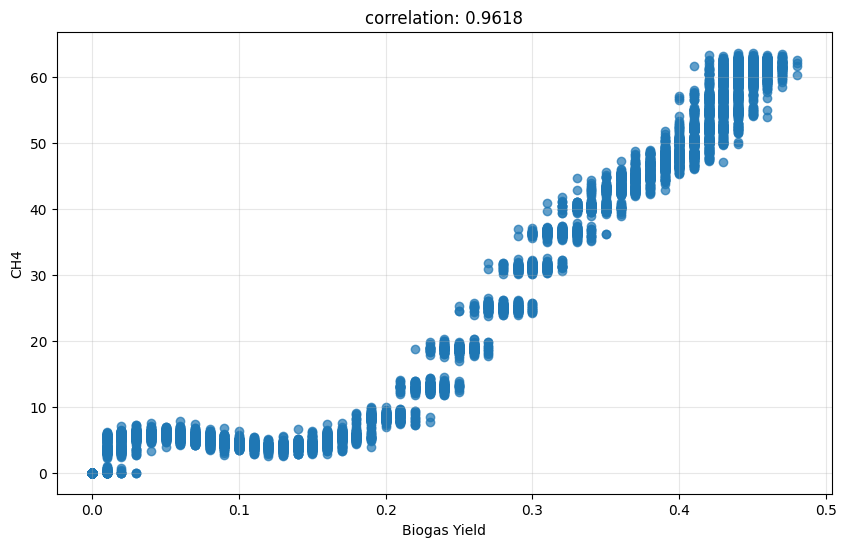

In [10]:
#for correlation of two columns
plt.figure(figsize=(10,6))
plt.scatter(biogas["Biogas Yield (m³/Kg)"], biogas["CH4 (%)"], alpha=0.7)
plt.title(f"correlation: {correlation:.4f}")
plt.xlabel("Biogas Yield")
plt.ylabel("CH4")
plt.grid(True,alpha=0.3)
plt.show()

In [11]:
# features (inputs) and targets (what we want to predict)
# think of features as clues we give the robot, an targets s the answers

FEATURES = [
    "Hydraulic Retention Time (Days)",
    "Temperature (°C)",           
    "pH"                       
]
TARGETS = [
    "Biogas Yield (m³/Kg)",          
    "CH4 (%)"
]
x = biogas[FEATURES].copy()
y = biogas[TARGETS].copy()

In [12]:
# sPLIT INTO tRAIN AND tEST SETS (LIKE HOMEWORK VS EXAM)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED
)

In [13]:
# Build a preprocessing + model pipeline
# We scale (StandardScaler) pH a little but trees don't need scaling
# Still, we keep a simple, safe setup for future swaps.

numeric_features = FEATURES
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ], remainder="drop"
)

# We use a RandomForest inside a MultiOutputRegressor to predict two targets at once
regressor = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators =300,
        max_depth=None,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
)

model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", regressor)
])

In [14]:
# Train the model (teach the robot)
print("\nTraining the model...")
model.fit(x_train, y_train)



Training the model...


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
# Evaluate on the test set (see how smart the robot is on new data)
y_pred = model.predict(x_test)

# The model predicts both Biogas and CH4 in one go; split them for metrics
biogas_true = y_test["Biogas Yield (m³/Kg)"].values      
ch4_true = y_test["CH4 (%)"].values
biogas_pred = y_pred[:,0]
ch4_pred = y_pred[:,1]

# Apply business rule to predictions: if predicted biogas <= 0, force CH4 =0
# (keeps things realistic)
ch4_pred = np.where(biogas_pred <= 0.0, 0.0, ch4_pred)
biogas_pred = np.clip(biogas_pred, 0.0, None)
ch4_pred = np.clip(ch4_pred, 0.0, None)

# Metrics: MAE (lower is better), R^2 (closer to 10 is better)
biogas_mae = mean_absolute_error(biogas_true, biogas_pred)
biogas_r2 = r2_score(biogas_true, biogas_pred)
ch4_mae = mean_absolute_error(ch4_true, ch4_pred)
ch4_r2 = r2_score(ch4_true, ch4_pred)

print("\nTest Metrics:")
print(f"Biogas Yield - MAE: {biogas_mae:.4f}, R^2: {biogas_r2:.4f}")
print(f"CH4 (PERCENT) = mae: {ch4_mae:.4f}, R^2: {ch4_r2:.4f}")



Test Metrics:
Biogas Yield - MAE: 0.0086, R^2: 0.9949
CH4 (PERCENT) = mae: 0.4787, R^2: 0.9991


In [ ]:
# Optional: quick plots (saves as PNGs so you can view the later)




In [16]:
# Cross-validation (extra safety check on trainingdata)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
# We'll measure R^2 for Biogas only as a quick example (multioutput CV is heavier)
cv_scores = cross_val_score(model, x_train, y_train[TARGETS],
                            cv=cv, scoring="r2")
print("\n5-Fold CV R^2 (Biogas): mean=%.3f std=%.3f" % (cv_scores.mean(), cv_scores.std()))



5-Fold CV R^2 (Biogas): mean=0.997 std=0.000


In [17]:
# Says the trained model  to disk so Streamlit can use it
os.makedirs("models", exist_ok=True)
MODEL_PATH = os.path.join("models", "biogas_model.joblib")
joblib.dump(model, MODEL_PATH)
print("\nSaved trained model to: ", MODEL_PATH)


Saved trained model to:  models\biogas_model.joblib


In [18]:
# Tiny helper: make a unction to predict with rule applied
# (We'll also reuse this idea inside the Streamlit app.)

def predict_biogas_and_ch4(h, t, pH):
    """Return (Biogas, ch4) prediction with business rule enforced."""
    X_in = pd.DataFrame({
        "Hydraulic Retention Time (Days)": [h],
        "Temperature (°C)": [t],
        "pH": [pH]
    })
    y_hat = model.predict(X_in)[0]
    biogas, ch4 = float(y_hat[0]), float(y_hat[1])
    # Enforce rule: when biogas is zero or negative, CH4 must be zero
    if biogas <= 0:
        ch4 = 0.0
        biogas = max(0.0, biogas)
        ch4 = max(0.0, ch4)
        return biogas, ch4
    
# Quick demo prediction
print("\nDemo prediction for HRT=10 days, Temp=30°C, pH=6.9:")
print(predict_biogas_and_ch4(20, 40, 5.4))



Demo prediction for HRT=10 days, Temp=30°C, pH=6.9:
None
